# Project Overview

This project evaluates a computer vision model for estimating a customer’s age from facial images. The goal is to determine whether age prediction could assist supermarkets in identifying customers who may require ID verification for alcohol purchases.

## Initialization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam

from PIL import Image
import os
import matplotlib.patheffects as pe

## Load Data

In [2]:
labels_df = pd.read_csv('/datasets/faces/labels.csv')

train_datagen = ImageDataGenerator(rescale=1./255)

## EDA

In [3]:
labels_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


In [4]:
print(labels_df.isna().sum())

file_name    0
real_age     0
dtype: int64


In [5]:
print(labels_df['file_name'].nunique())

7591


In [6]:
print(labels_df.shape)

(7591, 2)


In [7]:
print(labels_df['real_age'].min())
print(labels_df['real_age'].max())

1
100


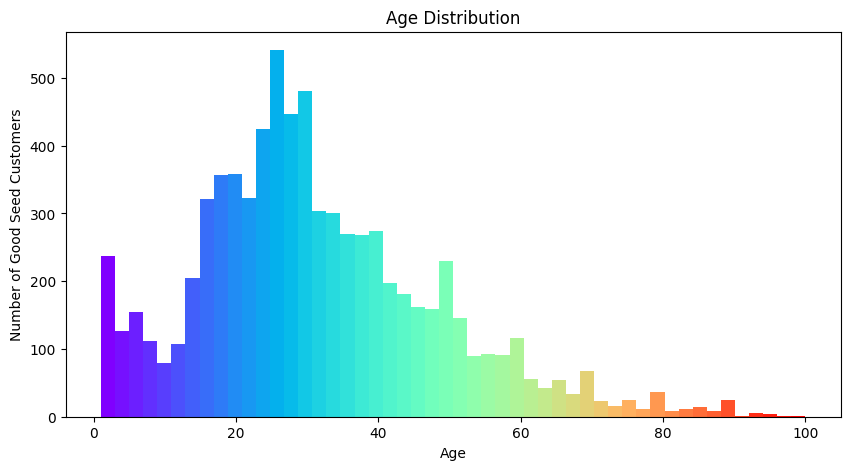

In [8]:
real_ages = labels_df['real_age']

plt.figure(figsize=(10, 5))
counts, bins, patches = plt.hist(real_ages, bins=50)

for patch, color in zip(patches, plt.cm.rainbow(np.linspace(0,1,len(patches)))):
    patch.set_facecolor(color)
    
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Good Seed Customers')
plt.show()

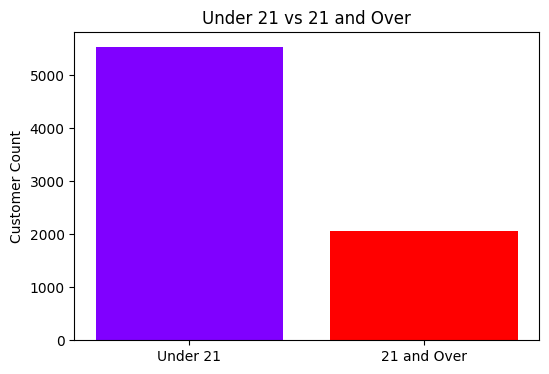

In [9]:
legal_age = labels_df['real_age'] >= 21
under_age = labels_df['real_age'] < 21

group_count= [
    legal_age.sum(),
     under_age.sum()]

categories=['Under 21','21 and Over']

colors=plt.cm.rainbow(np.linspace(0, 1, len(categories)))

plt.figure(figsize=(6, 4))
plt.bar(categories, group_count, color=colors)
plt.title('Under 21 vs 21 and Over')
plt.ylabel('Customer Count')
plt.show()

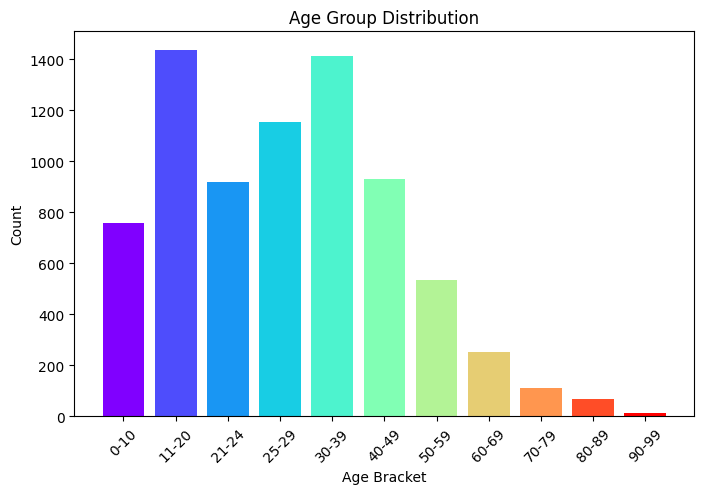

In [10]:
age_grouping = pd.cut(
    labels_df['real_age'],
    bins=[0, 11, 21, 25, 30, 40, 50, 60, 70, 80, 90, 100],
    labels=['0-10','11-20','21-24','25-29','30-39','40-49','50-59', '60-69','70-79','80-89','90-99']
)

age_grouping= age_grouping.value_counts().sort_index()
colors=plt.cm.rainbow(np.linspace(0, 1, len(age_grouping)))

plt.figure(figsize=(8,5))
plt.bar(age_grouping.index, age_grouping.values, color=colors)
plt.title('Age Group Distribution')
plt.xlabel('Age Bracket')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

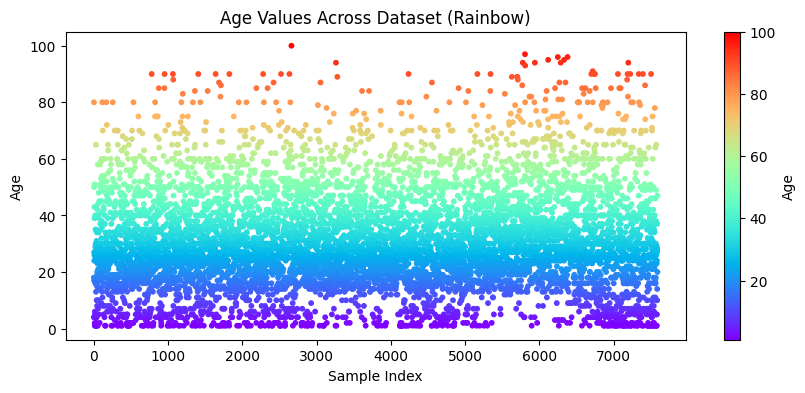

In [11]:
plt.figure(figsize=(10, 4))

plt.scatter(
    range(len(labels_df)),
    labels_df['real_age'],
    c=labels_df['real_age'],
    cmap='rainbow',
    s=10
)

plt.colorbar(label='Age')
plt.title('Age Values Across Dataset (Rainbow)')
plt.xlabel('Sample Index')
plt.ylabel('Age')
plt.show()

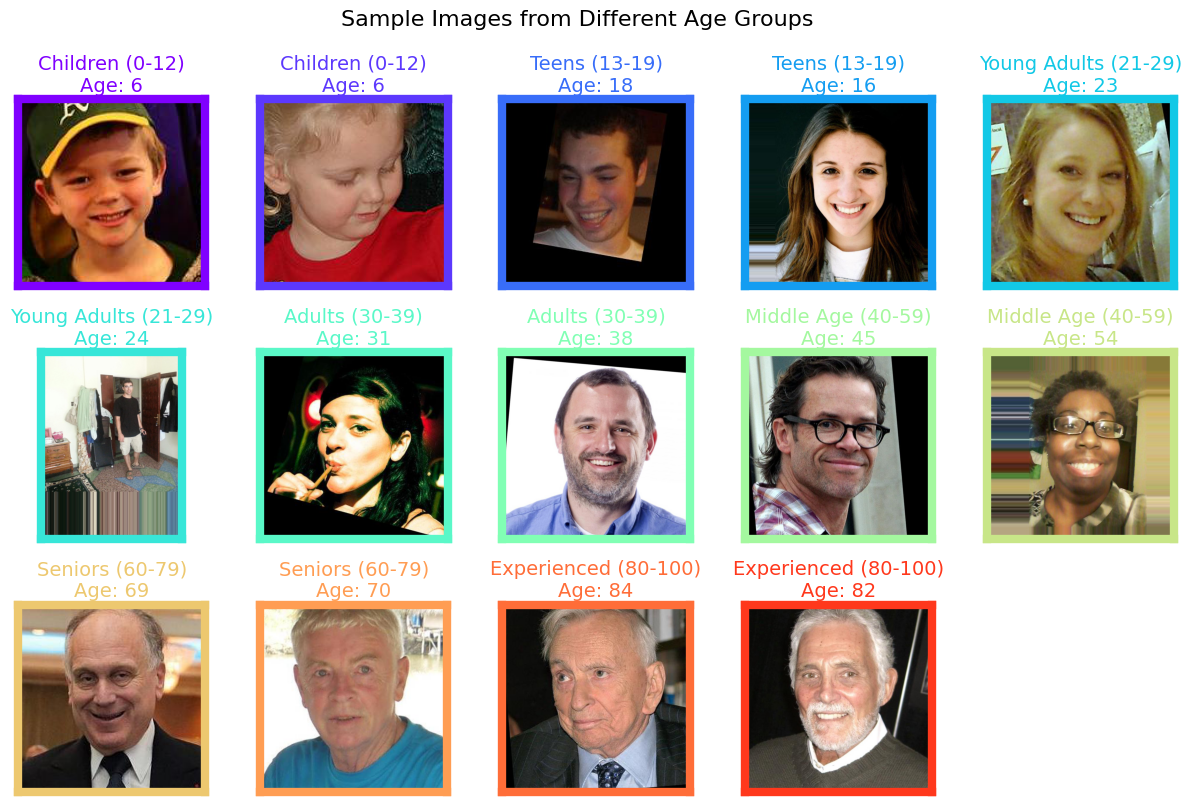

In [12]:
age_ranges = {
    'Children (0-12)': (0, 12),
    'Teens (13-19)': (13, 19),
    'Young Adults (21-29)': (21, 29),
    'Adults (30-39)': (30, 39),
    'Middle Age (40-59)': (40, 59),
    'Seniors (60-79)': (60, 79),
    'Experienced (80-100)': (80, 100)
}

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Sample Images from Different Age Groups', fontsize=16)

sample_count = 0
total_slots = 15
images_path = '/datasets/faces/final_files/'
colors = plt.cm.rainbow(np.linspace(0, 1, total_slots))

for age_group, (min_age, max_age) in age_ranges.items():
    age_subset = labels_df[(labels_df['real_age'] >= min_age) &
                           (labels_df['real_age'] <= max_age)]

    if len(age_subset) > 0:
        samples = age_subset.sample(min(2, len(age_subset)), random_state=42)

        for _, row in samples.iterrows():
            if sample_count >= total_slots:
                break

            img_path = os.path.join(images_path, row['file_name'])
            img = Image.open(img_path)

            row_idx = sample_count // 5
            col_idx = sample_count % 5

            ax = axes[row_idx, col_idx]
            ax.imshow(img)

            ax.set_title(f"{age_group}\nAge: {row['real_age']}",
                         color=colors[sample_count], fontsize=14)

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_frame_on(True)

            for spine in ax.spines.values():
                spine.set_edgecolor(colors[sample_count])
                spine.set_linewidth(6)
            sample_count += 1

for i in range(sample_count, total_slots):
    row_idx = i // 5
    col_idx = i % 5
    axes[row_idx, col_idx].axis('off')
plt.subplots_adjust(top=0.88, wspace=0.25, hspace=0.35)
plt.show()

## Findings

The dataset contains more than 7,000 labeled facial images with ages spanning from early childhood to older adulthood. The age distribution is concentrated more heavily among adults, with fewer observations at the youngest and oldest ends of the range. This imbalance may make age prediction less accurate for underrepresented age groups.

Visual inspection of sample images shows substantial variation in lighting, pose, facial expression, and image quality. These characteristics reflect realistic checkout conditions, but they also increase the difficulty of the task.

## Modeling

In [13]:
def load_train(path):
    """
    Loads training portion of the image dataset using a generator.
    """
    labels = pd.read_csv(path + 'labels.csv')
    
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=.25, horizontal_flip=True
    )
    
    train_datagen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(150, 150),
        batch_size=16,
        class_mode='raw',
        subset='training',
        shuffle=True,
        seed=12345)

    return train_datagen_flow

In [14]:
def load_test(path):
    
    """
    It loads the validation/test part of dataset from path
    """
    labels = pd.read_csv(path + 'labels.csv')

    test_datagen = ImageDataGenerator(
        rescale=1. / 255,
        validation_split=0.25
    )

    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(150, 150),
        batch_size=16,
        class_mode='raw',
        subset='validation',
        seed=12345,
        shuffle=False
    )

    return test_gen_flow

In [15]:
def create_model(input_shape):
    
    """
    It defines the model
    """
    
    backbone = ResNet50(
        weights='imagenet',
        input_shape=input_shape,
        include_top=False
    )

    model = Sequential([
        backbone,
        GlobalAveragePooling2D(),
        Dense(1, activation='relu')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='mse',
        metrics=['mae']
    )

    return model

In [16]:
def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):
    """
    Trains the model given the parameters
    """
    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)

    if validation_steps is None:
        validation_steps = len(test_data)

    model.fit(
        train_data,
        validation_data=test_data,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        verbose=2
    )

    return model

## GPU Training Script

In [17]:
init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    
    f.write(init_str)
    f.write('\n\n')
        
    for fn_name in [load_train, load_test, create_model, train_model]:
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')

## Training Output

Epoch 1/20 356/356 - 35s - loss: 95.3532 - mae: 7.4339 - val_loss: 124.3362 - val_mae: 8.4921 Epoch 2/20 356/356 - 35s - loss: 76.8372 - mae: 6.6707 - val_loss: 127.6357 - val_mae: 8.6035 Epoch 3/20 356/356 - 35s - loss: 69.9428 - mae: 6.3992 - val_loss: 91.1531 - val_mae: 7.4454 Epoch 4/20 356/356 - 35s - loss: 64.4249 - mae: 6.1407 - val_loss: 124.0287 - val_mae: 8.3481 Epoch 5/20 356/356 - 35s - loss: 52.8486 - mae: 5.5913 - val_loss: 109.1004 - val_mae: 8.2192 Epoch 6/20 356/356 - 35s - loss: 46.3094 - mae: 5.2223 - val_loss: 85.1038 - val_mae: 7.0332 Epoch 7/20 356/356 - 35s - loss: 38.2617 - mae: 4.7951 - val_loss: 92.0900 - val_mae: 7.3359 Epoch 8/20 356/356 - 35s - loss: 37.4804 - mae: 4.7402 - val_loss: 80.0016 - val_mae: 6.7239 Epoch 9/20 356/356 - 35s - loss: 33.5237 - mae: 4.4271 - val_loss: 83.2579 - val_mae: 6.8529 Epoch 10/20 356/356 - 35s - loss: 28.5170 - mae: 4.1411 - val_loss: 83.5056 - val_mae: 6.9629 Epoch 11/20 356/356 - 35s - loss: 27.0142 - mae: 3.9700 - val_loss: 92.1290 - val_mae: 7.1866 Epoch 12/20 356/356 - 35s - loss: 27.4564 - mae: 4.0428 - val_loss: 185.6307 - val_mae: 11.4591 Epoch 13/20 356/356 - 35s - loss: 23.7961 - mae: 3.7407 - val_loss: 92.3429 - val_mae: 7.2467 Epoch 14/20 356/356 - 35s - loss: 24.6167 - mae: 3.8116 - val_loss: 92.4542 - val_mae: 7.1401 Epoch 15/20 356/356 - 35s - loss: 22.2604 - mae: 3.6746 - val_loss: 82.5822 - val_mae: 6.7841 Epoch 16/20 356/356 - 35s - loss: 20.1899 - mae: 3.4430 - val_loss: 86.3830 - val_mae: 6.8304 Epoch 17/20 356/356 - 35s - loss: 17.3425 - mae: 3.2205 - val_loss: 78.4369 - val_mae: 6.6419 Epoch 18/20 356/356 - 35s - loss: 16.5249 - mae: 3.1295 - val_loss: 81.7731 - val_mae: 6.7226 Epoch 19/20 356/356 - 35s - loss: 16.6140 - mae: 3.1421 - val_loss: 80.9727 - val_mae: 6.9908 Epoch 20/20 356/356 - 35s - loss: 17.0187 - mae: 3.1785 - val_loss: 93.4115 - val_mae: 7.6512

## Conclusions

The model was able to learn meaningful age-related facial patterns, as shown by the improvement in training performance over time. However, the gap between training and validation metrics suggests overfitting and limited generalization to unseen images.

With a validation MAE of approximately 7 to 8 years, the model is not precise enough to serve as a standalone age-verification system for alcohol sales. A prediction error of that size creates too much uncertainty near the legal age threshold. Still, the model could be useful as a decision-support tool that flags potentially underage customers for manual ID checks.

Overall, this project demonstrates that computer vision can support retail age-screening workflows, but it should complement human verification rather than replace it.